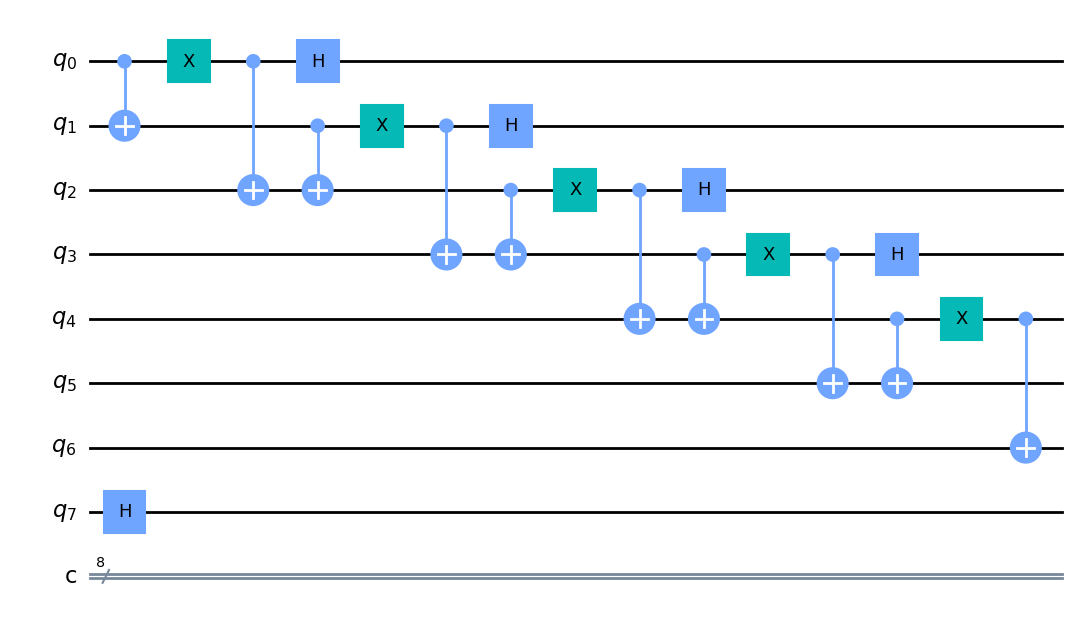

In [1]:
from adaptivedqc import Adaptivedqc
from qiskit import QuantumCircuit
from adaptivedqc.excute.runtime import IBMCloudRun
circuit = Adaptivedqc(8,8)
for i in range(5):
    circuit.cx(i%8,(i+1)%8)
    circuit.x(i%8)
    circuit.h((i-1)%8)
    circuit.cx(i%8,(i+2)%8)
circuit.draw('mpl')


allocation: [1, 1, 1, 1, 0, 0, 0, 0]
EPR num: 2.0
circuit depth: 23
circuit: global phase: 5π/4
                ┌───┐            ┌─────────┐┌────┐┌─────────┐                 »
q_0: ─────■─────┤ X ├──────■─────┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────────────────»
        ┌─┴─┐   └───┘      │     └─────────┘├───┬┘└─────────┘┌─────────┐┌────┐»
q_1: ───┤ X ├──────────────┼──────────■─────┤ X ├──────■─────┤ Rz(π/2) ├┤ √X ├»
        └───┘            ┌─┴─┐      ┌─┴─┐   └───┘      │     └─────────┘├───┬┘»
q_2: ────────────────────┤ X ├──────┤ X ├──────────────┼──────────■─────┤ X ├─»
                         └───┘      └───┘            ┌─┴─┐      ┌─┴─┐   └───┘ »
q_3: ────────────────────────────────────────────────┤ X ├──────┤ X ├─────────»
     ┌─────────┐┌────┐┌─────────┐   ┌───┐            └───┘      └───┘         »
q_4: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├───┤ f ├─────────────────────────────────────»
     └─────────┘└────┘└─────────┘   └───┘                                     »
q_5: ───────────────────

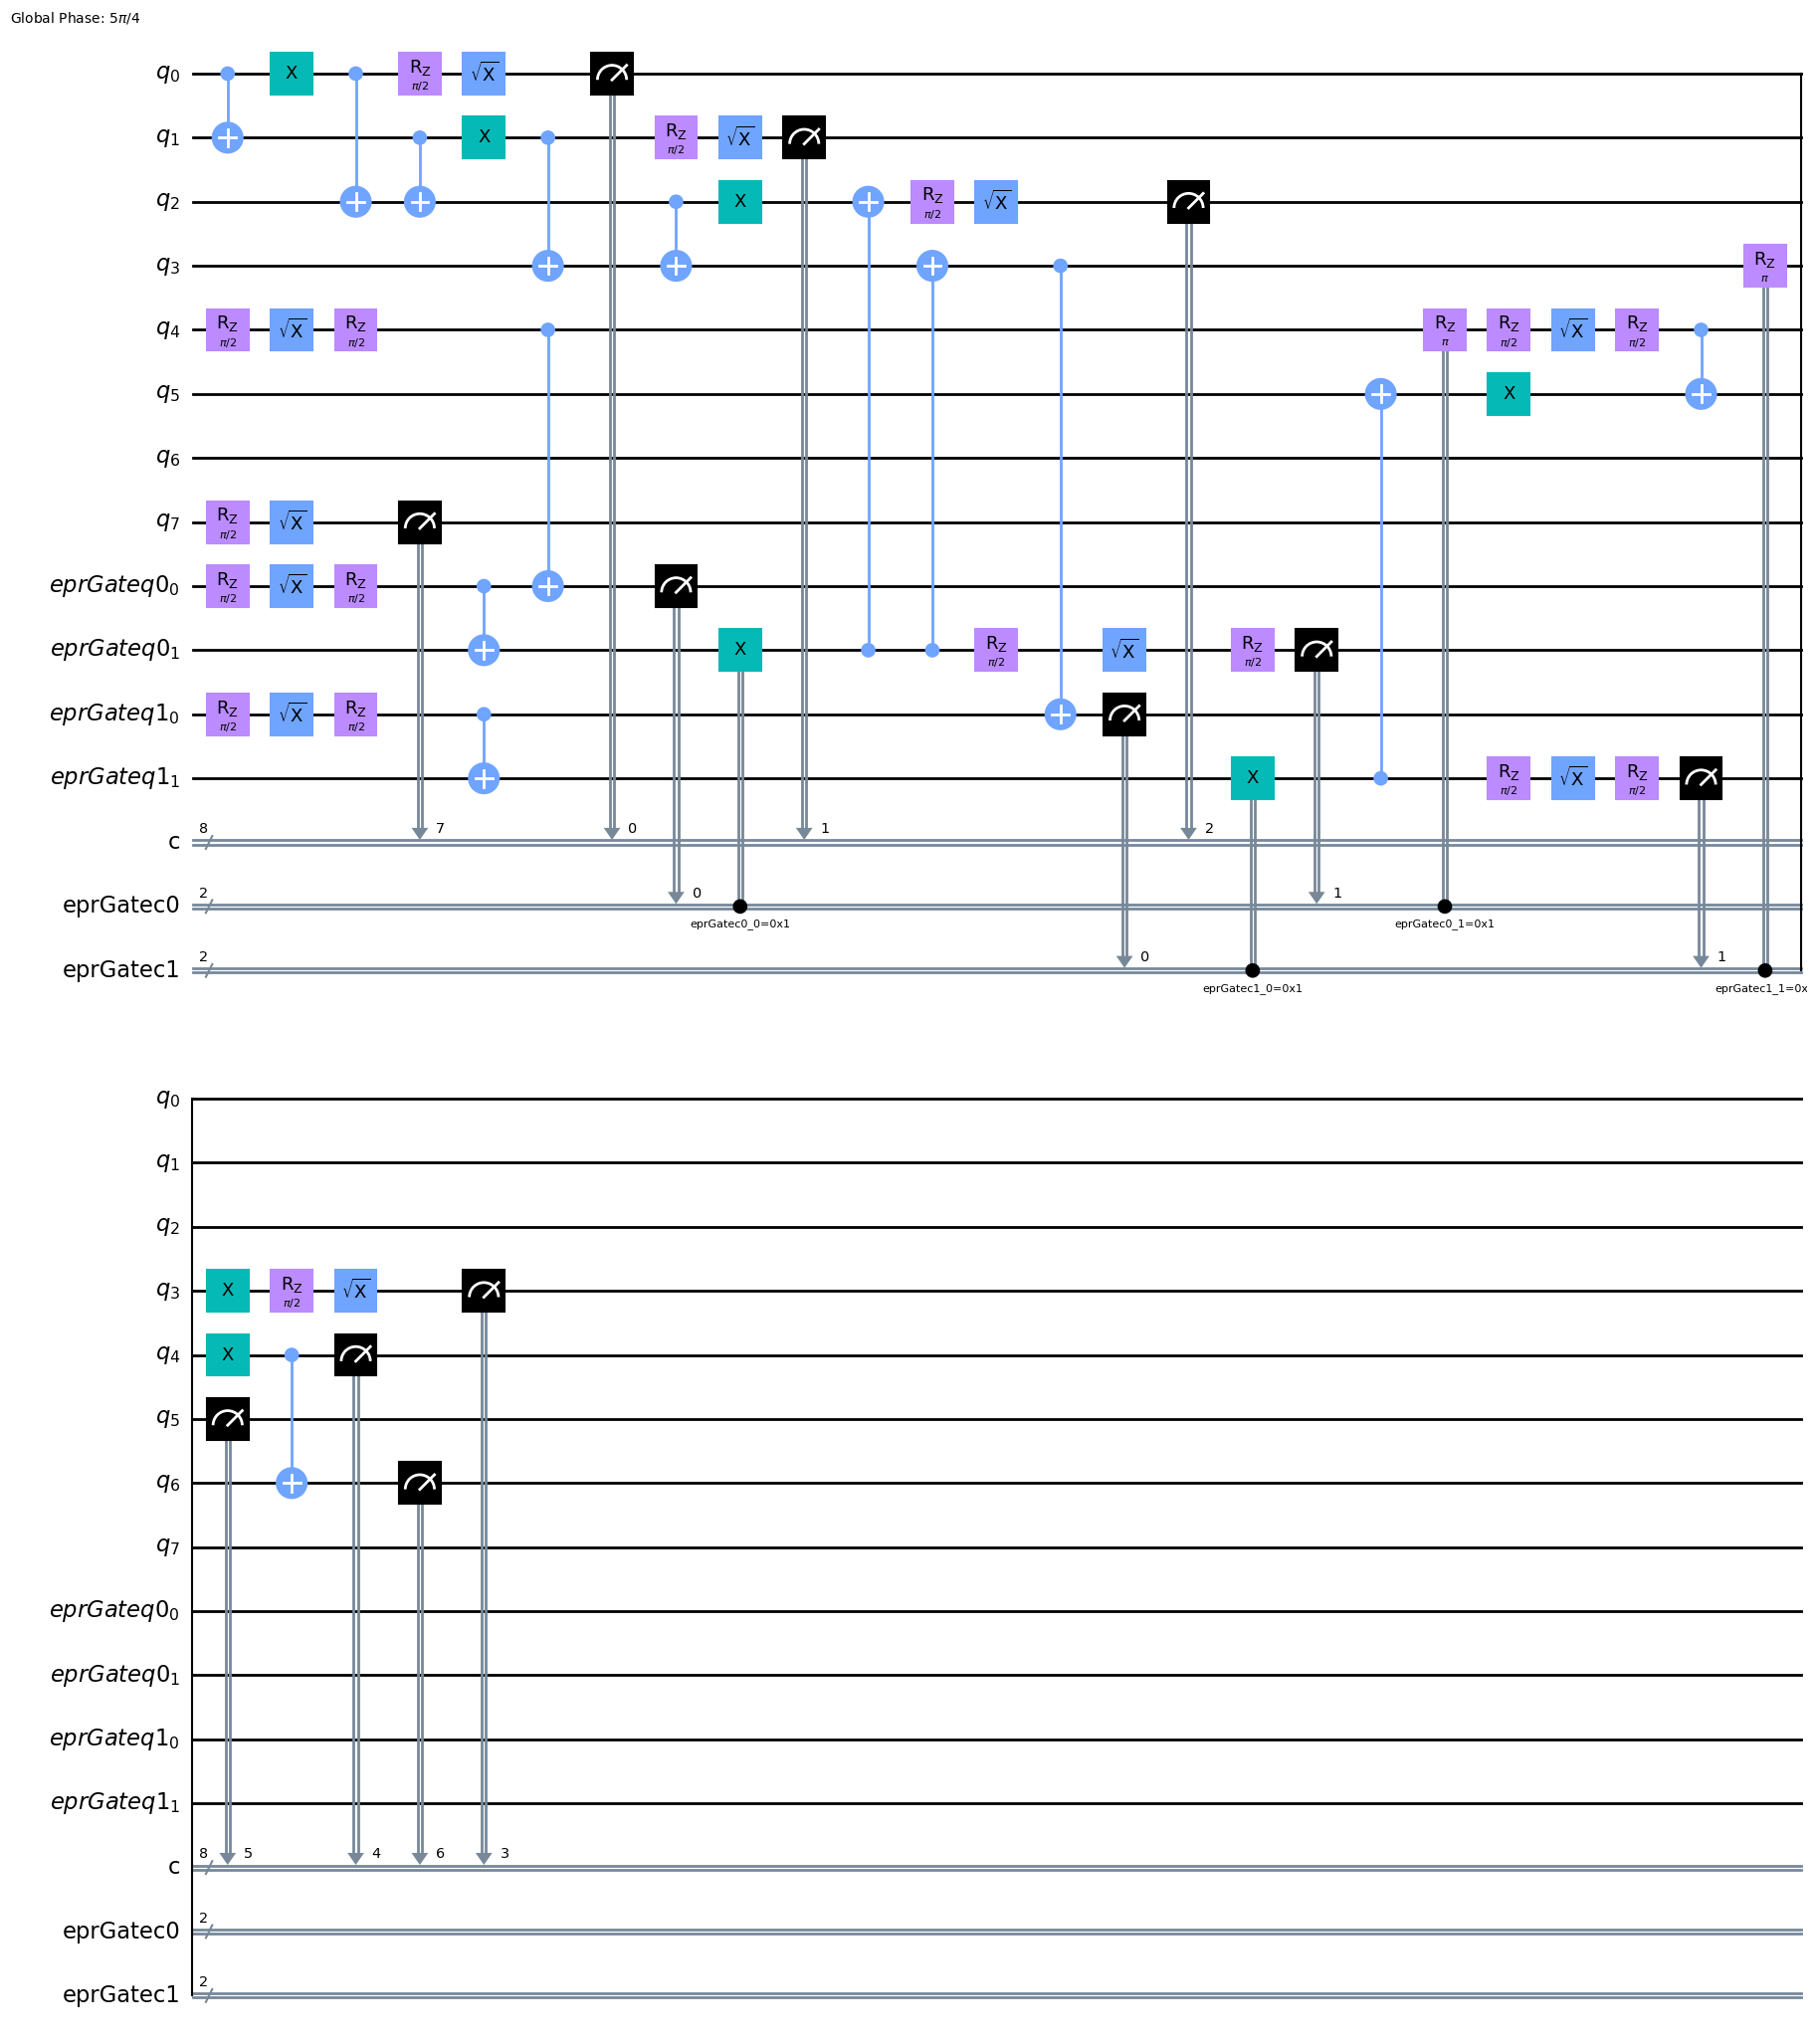

In [2]:
distirbute_circuit = circuit.run_on_part_qubits(width=4)
distirbute_circuit.draw('mpl')

In [3]:
from adaptivedqc.excute import IBMCloudRun
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
sim_ideal = AerSimulator()
noisemodel = NoiseModel.from_backend(IBMCloudRun().get_backend('ibmq_belem'))

In [11]:
AerSimulator.run(circuit,noise_model=noisemodel).result().get_counts()

AttributeError: 'NoiseModel' object has no attribute 'circular_shift'